In [1]:
%reset -f

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoLocator
from matplotlib.transforms import ScaledTranslation
plt.rcParams.update({'font.size': 16})
import seaborn as sns
import matplotlib.dates as mdates
import nrarfcn as nr

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Map plotting imports
import geopandas as gpd
from bokeh.plotting import figure, show#, output_notebook
# output_notebook()
from bokeh.models import ColumnDataSource, LinearColorMapper, ColorBar, HoverTool, WheelZoomTool, WMTSTileSource, Arrow, NormalHead
from bokeh.palettes import Viridis256, Bokeh
from bokeh.io import output_file
from bokeh.transform import factor_cmap
import random
from bokeh.io import output_notebook
output_notebook()

Loading BokehJS ...

In [2]:
def load_csv(name):
    # This enables loading CSVs and pd.to_datetime simultaneously
    return pd.read_csv(f"2026q3-ndCbrsCbandInterference/_data/{name}.csv", parse_dates=['Time'], low_memory=False)

# lteRadio = load_csv('lte_radio')
# ltePdsch = load_csv('lte_pdsch')
# ltePusch = load_csv('lte_pusch')
nrRadio = load_csv('nr_radio')
# nrRadioBeam = load_csv('nr_radio_beam')
nrPdsch = load_csv('nr_pdsch')
nrPusch = load_csv('nr_pusch')

In [3]:
nrPusch.columns

Index(['Time', 'Database', 'Collection', 'Latitude', 'Longitude', 'Operator',
       'Serial Number', 'Model', 'RAN Configuration', 'Band Number',
       'PCI 5G NR', 'SSB Index', 'UL NR-ARFCN', 'UL Point A NR-ARFCN',
       'UL Point A Frequency', 'UL Subcarrier Spacing', 'UL Bandwidth',
       'UL Bandwidth Aggregated', 'Cell Type', 'Max PUSCH Layers',
       'Avg PUSCH Layers', 'PUSCH SCS', 'Enabled256QAM',
       '5G NR Net PUSCH Throughput', 'PUSCH Avg RBs per Slot', 'PUSCH RBs',
       'MCS', 'PUSCH Used Slots', 'Bytes Transferred over PUSCH',
       'PUSCH Available Slots', 'PUSCH Slot Utilization',
       'PUSCH Avg RBs all Slots', 'PUSCH Tx Power', 'DL Pathloss',
       'PUSCH ReTx Rate', '1 Layer', '2 Layers', '3 Layers', '4 Layers',
       '5 Layers', '6 Layers', '7 Layers', '8 Layers', 'Num Slots',
       'Slot Pattern', 'Num Patterns', 'Pattern1 Periodicity',
       'Pattern1 UL Slots', 'Pattern1 UL Symbols', 'Pattern2 Periodicity',
       'Pattern2 UL Slots', 'Pattern2 UL

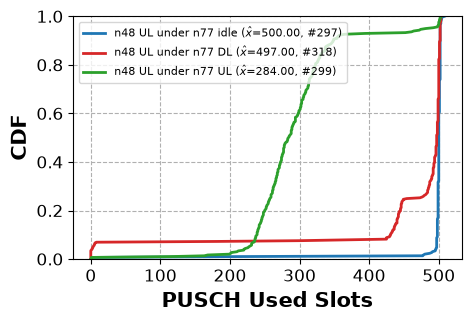

In [7]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrPusch.loc[nrPusch['Collection'] == 'C_076', 'PUSCH Used Slots'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"n48 UL under n77 idle ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'C_081', 'PUSCH Used Slots'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"n48 UL under n77 DL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:red"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'C_083', 'PUSCH Used Slots'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"n48 UL under n77 UL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:green"
)

ax.set_xlabel("PUSCH Used Slots", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

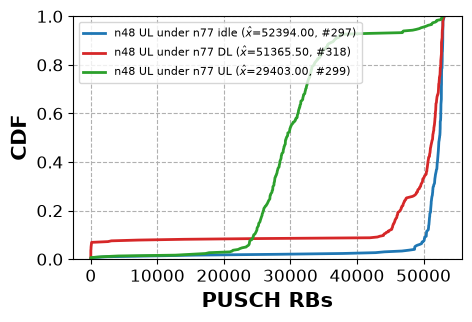

In [8]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(5, 3.5))

df_temp = nrPusch.loc[nrPusch['Collection'] == 'C_076', 'PUSCH RBs'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"n48 UL under n77 idle ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:blue"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'C_081', 'PUSCH RBs'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"n48 UL under n77 DL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:red"
)

df_temp = nrPusch.loc[nrPusch['Collection'] == 'C_083', 'PUSCH RBs'].dropna().sort_values()
ax.plot(
    df_temp, np.linspace(0, 1, df_temp.shape[0]),
    label=rf"n48 UL under n77 UL ($\hat{{x}}$={df_temp.median():.2f}, #{df_temp.shape[0]})",
    linewidth=2, linestyle="solid", color="tab:green"
)

ax.set_xlabel("PUSCH RBs", fontsize=15, fontweight="bold")
ax.set_ylabel("CDF", fontsize=15, fontweight="bold")
ax.set_ylim(0, 1)
ax.yaxis.set_minor_locator(AutoLocator())
ax.grid(True, linestyle="--", which="both", axis="both")
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()